# Ley de los Grandes Números
### Convergencia, Estimadores y Parámetros

**Magíster en Ciencia de Datos e Inteligencia Artificial** · Universidad Andrés Bello

Maidana, J.P. (2026)

---

> **Cómo usar este cuaderno.** Ejecuta las celdas en orden de arriba hacia abajo. Algunas celdas de visualización reutilizan variables (la población, los estimadores) generadas en la celda inmediatamente anterior, así que conviene correrlas en secuencia. Empieza por la celda de configuración.

In [1]:
# ---------------------------------------------------------------
# CONFIGURACIÓN — ejecutar primero
# ---------------------------------------------------------------
# Requisitos: numpy, scipy, matplotlib (preinstalados en Google Colab).
# Si te faltara alguno, descomenta:
# !pip install numpy scipy matplotlib

%matplotlib inline
import numpy as np
print("Entorno listo. Ejecuta las celdas en orden.")

Entorno listo. Ejecuta las celdas en orden.


## 1. Introducción: De la Muestra a la Población

Imaginemos una situación práctica. Trabajas en una empresa de e-commerce y necesitas estimar el tiempo promedio que los usuarios pasan en el sitio web. Tienes millones de usuarios, pero solo puedes observar una muestra de 1,000.

Te preguntas: ¿Es confiable el promedio que calculo con estos 1,000 usuarios? Si tomo otra muestra diferente de 1,000 usuarios, ¿obtendré un promedio muy distinto? ¿Cuántos usuarios necesito observar para tener confianza en mi estimación?

Estas preguntas están en el corazón de la inferencia estadística. La **Ley de los Grandes Números** proporciona el fundamento matemático que justifica por qué podemos hacer inferencias sobre poblaciones completas observando solo muestras.

**El problema fundamental:** en la práctica, rara vez tenemos acceso a toda la población. Consideremos algunos ejemplos:

- **Control de Calidad:** No puedes probar todas las baterías producidas (prueba destructiva)
- **Encuestas:** Es imposible y costoso encuestar a toda la población de un país
- **Medicina:** Los ensayos clínicos usan muestras, no toda la población de pacientes
- **Machine Learning:** Entrenamos con un subset de datos, pero queremos generalizar
- **A/B Testing:** Observamos comportamiento en una ventana temporal, pero queremos inferir para el futuro

La estadística inferencial nos permite hacer afirmaciones sobre parámetros poblacionales usando solo estadísticos muestrales. Pero, ¿cuándo es válido hacer esto? ¿Qué garantías matemáticas tenemos?

> 🔵 **Población** &nbsp; $N$ muy grande &nbsp;·&nbsp; **parámetro** $\mu$ *(desconocido)*
> &nbsp;&nbsp;—— muestreo ——▶&nbsp;&nbsp;
> 🟢 **Muestra** &nbsp; $n$ pequeño &nbsp;·&nbsp; **estimador** $\bar{x}$
>
> &nbsp;&nbsp;&nbsp;&nbsp;❓ *¿Qué tan bien $\bar{x}$ estima $\mu$?*

> **📝 Nota — Lo que aprenderás**
>
> 1. La diferencia fundamental entre parámetro poblacional y estimador muestral
> 2. La Ley de los Grandes Números (débil y fuerte) y qué garantizan
> 3. Tipos de convergencia estocástica
> 4. Por qué los estimadores varían y cómo cuantificar esa variabilidad
> 5. Propiedades deseables de estimadores (insesgado, consistente, eficiente)
> 6. Cómo visualizar y verificar convergencia computacionalmente
> 7. Aplicaciones prácticas en ciencia de datos

## 2. Parámetros vs Estimadores: La Distinción Fundamental

### 2.1 Conceptos Básicos

> **📘 Definición — Parámetro Poblacional**
>
> Un **parámetro** es una característica numérica de la población completa. Es un valor fijo pero generalmente desconocido.
>
> **Notación común:**
> - $\mu$ : Media poblacional
> - $\sigma^2$ : Varianza poblacional
> - $\sigma$ : Desviación estándar poblacional
> - $p$ : Proporción poblacional
> - $\rho$ : Coeficiente de correlación poblacional
>
> **Ejemplo:** La altura promedio de todos los adultos en Chile es un parámetro. Es un número fijo (aunque desconocido).

> **📘 Definición — Estimador Muestral**
>
> Un **estimador** (o estadístico) es una función de los datos muestrales que se usa para estimar un parámetro poblacional. Es una variable aleatoria porque depende de la muestra específica obtenida.
>
> **Notación común:**
> - $\bar{X}$ o $\bar{x}$ : Media muestral
> - $S^2$ o $s^2$ : Varianza muestral
> - $S$ o $s$ : Desviación estándar muestral
> - $\hat{p}$ : Proporción muestral
> - $r$ : Coeficiente de correlación muestral
>
> **Ejemplo:** Si mides la altura de 100 adultos chilenos y calculas su promedio, ese promedio es un estimador de $\mu$. Si tomas otra muestra de 100, obtendrás un promedio ligeramente diferente.

### 2.2 La Distinción es Fundamental

| Característica | Parámetro | Estimador |
|:---|:---:|:---:|
| Naturaleza | Valor fijo | Variable aleatoria |
| Conocimiento | Generalmente desconocido | Calculable |
| Notación | Letras griegas ($\mu, \sigma$) | Letras latinas ($\bar{x}, s$) |
| Variabilidad | No varía | Varía entre muestras |
| Población/Muestra | Población completa | Muestra específica |

**Un ejemplo concreto:** supongamos que la población son todos los smartphones producidos por una fábrica en un año (10 millones de unidades). La duración promedio real de batería es $\mu = 15.2$ horas: este es el parámetro.

Como fabricante, no puedes probar los 10 millones de teléfonos. Entonces tomas una muestra aleatoria de 100 y mides sus baterías. El promedio de esos 100 es $\bar{x} = 15.5$ horas: este es tu estimador. Si tomaras otra muestra de 100, podrías obtener $\bar{x} = 14.9$ horas. El estimador varía; el parámetro $\mu = 15.2$ no cambia.

> **🟢 Ejemplo — Visualización de la Variabilidad del Estimador**
>
> Generamos una población conocida y tomamos 1000 muestras distintas de tamaño 100 para ver cómo varía la media muestral alrededor del parámetro verdadero.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Simulación: población conocida
rng = np.random.default_rng(42)
poblacion = rng.normal(loc=15.2, scale=2.0, size=10_000_000)

mu_real = poblacion.mean()
print(f"Parámetro μ real: {mu_real:.4f} horas")

# 1000 muestras distintas de tamaño 100
n_muestras = 1000
tamaño_muestra = 100
estimadores = np.array([
    rng.choice(poblacion, size=tamaño_muestra, replace=False).mean()
    for _ in range(n_muestras)
])

print(f"\nEstadísticas de los estimadores:")
print(f"  Media: {estimadores.mean():.4f}")
print(f"  Desv. Est: {estimadores.std():.4f}")
print(f"  Mínimo: {estimadores.min():.4f}")
print(f"  Máximo: {estimadores.max():.4f}")

Parámetro μ real: 15.2001 horas

Estadísticas de los estimadores:
  Media: 15.2057
  Desv. Est: 0.1959
  Mínimo: 14.6131
  Máximo: 15.9270


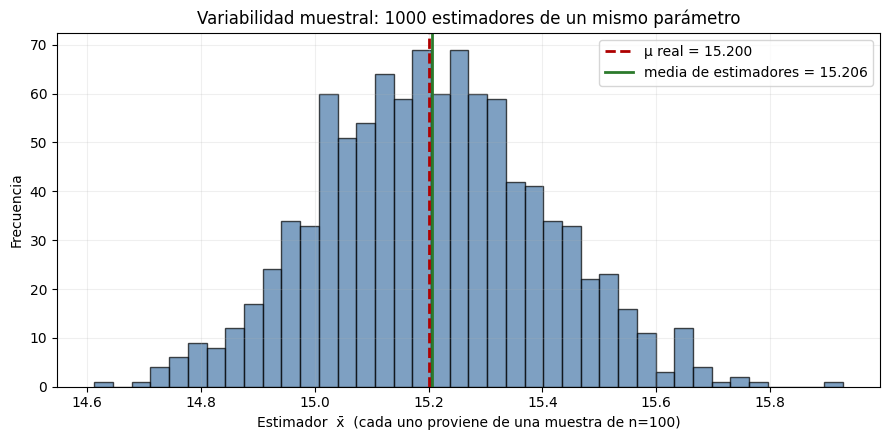

In [3]:
# --- Visualización (agregada al convertir: el examplebox se titula
#     "Visualización…" pero el listado del apunte solo imprime la tabla) ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(estimadores, bins=40, edgecolor="black", alpha=0.7, color="#4878a8")
ax.axvline(mu_real, color="#ae0000", linestyle="--", linewidth=2,
           label=f"μ real = {mu_real:.3f}")
ax.axvline(estimadores.mean(), color="#2c7a2c", linestyle="-", linewidth=2,
           label=f"media de estimadores = {estimadores.mean():.3f}")
ax.set_xlabel("Estimador  x̄  (cada uno proviene de una muestra de n=100)")
ax.set_ylabel("Frecuencia")
ax.set_title("Variabilidad muestral: 1000 estimadores de un mismo parámetro")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Observaciones importantes:**

1. Los estimadores varían alrededor del parámetro verdadero.
2. La media de los estimadores está cerca del parámetro (esto se llama *insesgamiento*).
3. Hay dispersión en los estimadores (esta es la *variabilidad muestral*).
4. Ningún estimador individual es exactamente igual al parámetro.

## 3. La Ley de los Grandes Números

### 3.1 Intuición

La Ley de los Grandes Números (LGN) es uno de los resultados más importantes en probabilidad y estadística. Establece intuitivamente:

> *A medida que el tamaño de la muestra aumenta, el promedio muestral se acerca al promedio poblacional.*

Más formalmente, garantiza que el estimador converge al parámetro cuando $n \to \infty$.

### 3.2 Versión Débil (WLLN)

> **📘 Definición — Ley Débil de los Grandes Números**
>
> Sea $X_1, X_2, \ldots, X_n$ una secuencia de variables aleatorias independientes e idénticamente distribuidas (i.i.d.) con media $\mu$ y varianza finita $\sigma^2 < \infty$.
>
> La media muestral es:
>
> $$\bar{X}_n = \frac{1}{n}\sum_{i=1}^{n} X_i$$
>
> Entonces, para cualquier $\epsilon > 0$:
>
> $$\lim_{n \to \infty} P(|\bar{X}_n - \mu| < \epsilon) = 1 \qquad \Longleftrightarrow \qquad \lim_{n \to \infty} P(|\bar{X}_n - \mu| \geq \epsilon) = 0$$
>
> **En palabras:** La probabilidad de que el promedio muestral esté dentro de $\epsilon$ del parámetro $\mu$ tiende a 1 cuando $n$ aumenta.

**¿Qué significa "convergencia en probabilidad"?** No significa que $\bar{X}_n$ eventualmente sea igual a $\mu$. Significa que la probabilidad de que $\bar{X}_n$ esté lejos de $\mu$ se vuelve arbitrariamente pequeña para $n$ suficientemente grande.

> **🔶 Importante — Condiciones necesarias para la LGN**
>
> 1. **Independencia:** Las observaciones deben ser independientes
> 2. **Idénticamente distribuidas:** Todas vienen de la misma distribución
> 3. **Media finita:** $E[X_i] = \mu < \infty$
> 4. **Varianza finita:** $\text{Var}(X_i) = \sigma^2 < \infty$ (para versión débil)
>
> Existen versiones generalizadas que relajan algunas de estas condiciones, pero las anteriores son las más habituales.

### 3.3 Versión Fuerte (SLLN)

> **📘 Definición — Ley Fuerte de los Grandes Números**
>
> Bajo las mismas condiciones que la WLLN, la versión fuerte garantiza:
>
> $$P\!\left(\lim_{n \to \infty} \bar{X}_n = \mu\right) = 1$$
>
> **En palabras:** Con probabilidad 1, la secuencia $\bar{X}_n$ converge al valor $\mu$ cuando $n \to \infty$.

**Diferencia entre versión débil y fuerte:**

- **Débil:** Para cada $\epsilon$ fijo, la probabilidad de desviarse más de $\epsilon$ tiende a 0.
- **Fuerte:** La secuencia completa converge a $\mu$ (convergencia *casi segura*).

La versión fuerte implica la débil, pero no viceversa. En la práctica, ambas versiones justifican que podemos estimar parámetros con muestras grandes.

### 3.4 Demostración Computacional

Generamos una secuencia larga de observaciones y calculamos la media acumulada: cómo evoluciona $\bar{X}_n$ a medida que incorporamos más datos.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

mu_real = 5.0
sigma_real = 2.0

# Secuencia de n_max observaciones
n_max = 10000
datos = rng.normal(loc=mu_real, scale=sigma_real, size=n_max)

# Media acumulativa
media_acumulativa = np.cumsum(datos) / np.arange(1, n_max + 1)

# Valores en puntos clave
puntos = [10, 50, 100, 500, 1000, 5000, 10000]
print("Convergencia de la media muestral:")
print("-" * 50)
for n in puntos:
    valor = media_acumulativa[n - 1]
    error = abs(valor - mu_real)
    print(f"n = {n:>5}: x̄ = {valor:.6f}, error = {error:.6f}")

Convergencia de la media muestral:
--------------------------------------------------
n =    10: x̄ = 4.328857, error = 0.671143
n =    50: x̄ = 5.182422, error = 0.182422
n =   100: x̄ = 4.899461, error = 0.100539
n =   500: x̄ = 4.973748, error = 0.026252
n =  1000: x̄ = 4.942217, error = 0.057783
n =  5000: x̄ = 4.960246, error = 0.039754
n = 10000: x̄ = 4.979500, error = 0.020500


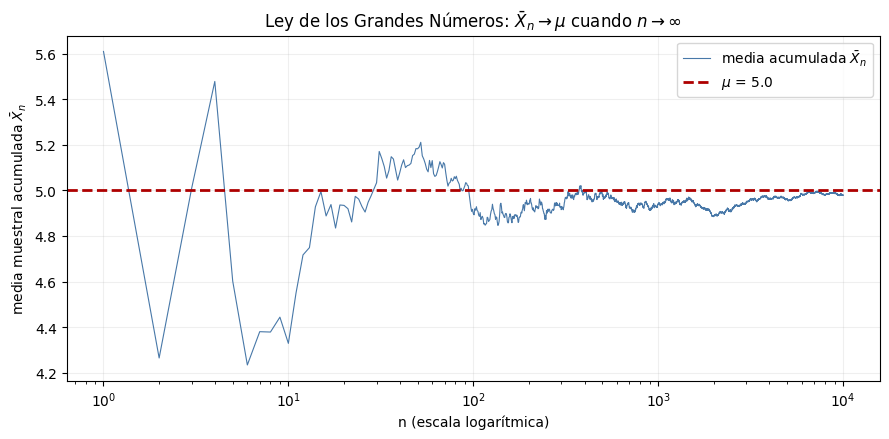

In [5]:
# --- Visualización de la convergencia (agregada al convertir) ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(np.arange(1, n_max + 1), media_acumulativa,
        color="#4878a8", linewidth=0.8, label=r"media acumulada $\bar{X}_n$")
ax.axhline(mu_real, color="#ae0000", linestyle="--", linewidth=2,
           label=fr"$\mu$ = {mu_real}")
ax.set_xscale("log")
ax.set_xlabel("n (escala logarítmica)")
ax.set_ylabel(r"media muestral acumulada $\bar{X}_n$")
ax.set_title(r"Ley de los Grandes Números: $\bar{X}_n \to \mu$ cuando $n \to \infty$")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Al principio ($n$ pequeño) hay mucha variabilidad; a medida que $n$ aumenta, la media se estabiliza cerca de $\mu = 5$ y el error disminuye progresivamente.

## 4. Tipos de Convergencia

Existen diferentes nociones de convergencia en probabilidad. La LGN involucra convergencia *en probabilidad*, pero hay otras igualmente importantes:

| Tipo | Definición Informal |
|:---|:---|
| **Casi segura** | La secuencia converge excepto en un conjunto de probabilidad cero |
| **En probabilidad** | La probabilidad de desviaciones grandes tiende a cero |
| **En distribución** | Las funciones de distribución convergen puntualmente |
| **En media cuadrática** | El valor esperado del error cuadrático tiende a cero |

**Relaciones entre tipos de convergencia** (las flechas indican implicación):

> **Casi segura** $\;\Rightarrow\;$ **En probabilidad** $\;\Rightarrow\;$ **En distribución**
>
> **En media cuadrática** $\;\Rightarrow\;$ **En probabilidad**

**Para la LGN:**

- SLLN garantiza convergencia *casi segura*
- WLLN garantiza convergencia *en probabilidad*
- El Teorema Central del Límite involucra convergencia *en distribución*

## 5. Variabilidad de Estimadores

### 5.1 ¿Por qué los Estimadores Varían?

Los estimadores son funciones de muestras aleatorias. Diferentes muestras producen diferentes estimadores. Esta variabilidad es inherente y cuantificable.

> **📘 Definición — Error Estándar**
>
> El **error estándar** (SE) de un estimador es su desviación estándar. Mide la variabilidad típica del estimador entre muestras.
>
> Para la media muestral:
>
> $$SE(\bar{X}) = \frac{\sigma}{\sqrt{n}}$$
>
> donde $\sigma$ es la desviación estándar poblacional y $n$ es el tamaño de muestra.
>
> **Interpretación:** El SE indica qué tan dispersos están los valores del estimador alrededor del parámetro verdadero.

**Propiedades importantes del error estándar:**

1. $SE \propto 1/\sqrt{n}$: disminuye con el tamaño de muestra.
2. Para reducir el SE a la mitad, se necesitan 4 veces más datos.
3. Para reducirlo a un décimo, se necesitan 100 veces más datos.
4. Nunca llega a cero (a menos que $n \to \infty$).

In [6]:
import numpy as np

rng = np.random.default_rng(42)
mu, sigma = 50, 10
tamaños = np.array([10, 20, 50, 100, 200, 500, 1000, 2000, 5000])
n_simulaciones = 10000

print("Tamaño de muestra vs Error Estándar:")
print("-" * 60)
for n in tamaños:
    medias = np.array([
        rng.normal(mu, sigma, size=n).mean()
        for _ in range(n_simulaciones)
    ])
    se_emp = medias.std()
    se_teo = sigma / np.sqrt(n)
    print(f"n = {n:>5}: SE empírico = {se_emp:.4f}, "
          f"SE teórico = {se_teo:.4f}")

Tamaño de muestra vs Error Estándar:
------------------------------------------------------------
n =    10: SE empírico = 3.1775, SE teórico = 3.1623
n =    20: SE empírico = 2.2170, SE teórico = 2.2361
n =    50: SE empírico = 1.4007, SE teórico = 1.4142


n =   100: SE empírico = 0.9973, SE teórico = 1.0000
n =   200: SE empírico = 0.7084, SE teórico = 0.7071
n =   500: SE empírico = 0.4503, SE teórico = 0.4472


n =  1000: SE empírico = 0.3164, SE teórico = 0.3162


n =  2000: SE empírico = 0.2229, SE teórico = 0.2236


n =  5000: SE empírico = 0.1425, SE teórico = 0.1414


### 5.2 Distribución Muestral

> **📘 Definición — Distribución Muestral**
>
> La **distribución muestral** de un estimador es la distribución de probabilidad de ese estimador considerando todas las posibles muestras del mismo tamaño.
>
> Para la media muestral $\bar{X}$ de una población con media $\mu$ y varianza $\sigma^2$:
> - $E[\bar{X}] = \mu$
> - $\text{Var}(\bar{X}) = \dfrac{\sigma^2}{n}$
> - $SE(\bar{X}) = \dfrac{\sigma}{\sqrt{n}}$
>
> **Teorema Central del Límite:** Para $n$ suficientemente grande, la distribución de $\bar{X}$ es aproximadamente normal, independientemente de la distribución original:
>
> $$\bar{X} \sim N\!\left(\mu,\, \frac{\sigma^2}{n}\right) \quad \text{(aproximadamente para } n \text{ grande)}$$

> **🟢 Ejemplo — Visualización de la Distribución Muestral con Población Exponencial**
>
> Aunque la población es exponencial (muy asimétrica), la distribución de la media se aproxima a normal a medida que $n$ crece. El test de Kolmogorov–Smirnov (KS) lo confirma: su $p$-valor crece con $n$.

In [7]:
import numpy as np
from scipy import stats

rng = np.random.default_rng(42)

# Población exponencial (muy asimétrica)
poblacion = rng.exponential(scale=5.0, size=1_000_000)
mu_real    = poblacion.mean()
sigma_real = poblacion.std()

print(f"μ = {mu_real:.4f},  σ = {sigma_real:.4f}")

# Distribuciones muestrales para distintos n
tamaños   = [5, 10, 30, 100]
n_muestras = 5000

for n in tamaños:
    medias = np.array([
        rng.choice(poblacion, size=n, replace=False).mean()
        for _ in range(n_muestras)
    ])
    se_teo = sigma_real / np.sqrt(n)
    ks_stat, p_val = stats.kstest(
        (medias - mu_real) / medias.std(), 'norm'
    )
    print(f"n = {n:>3}: SE_emp = {medias.std():.4f}, "
          f"SE_teo = {se_teo:.4f}, KS p = {p_val:.3f}")

# Observación: aunque la población es exponencial (asimétrica),
# la distribución de la media se aproxima a normal con n creciente.

μ = 4.9990,  σ = 4.9990
n =   5: SE_emp = 2.2339, SE_teo = 2.2356, KS p = 0.000
n =  10: SE_emp = 1.5969, SE_teo = 1.5808, KS p = 0.000


n =  30: SE_emp = 0.9163, SE_teo = 0.9127, KS p = 0.000
n = 100: SE_emp = 0.5013, SE_teo = 0.4999, KS p = 0.061


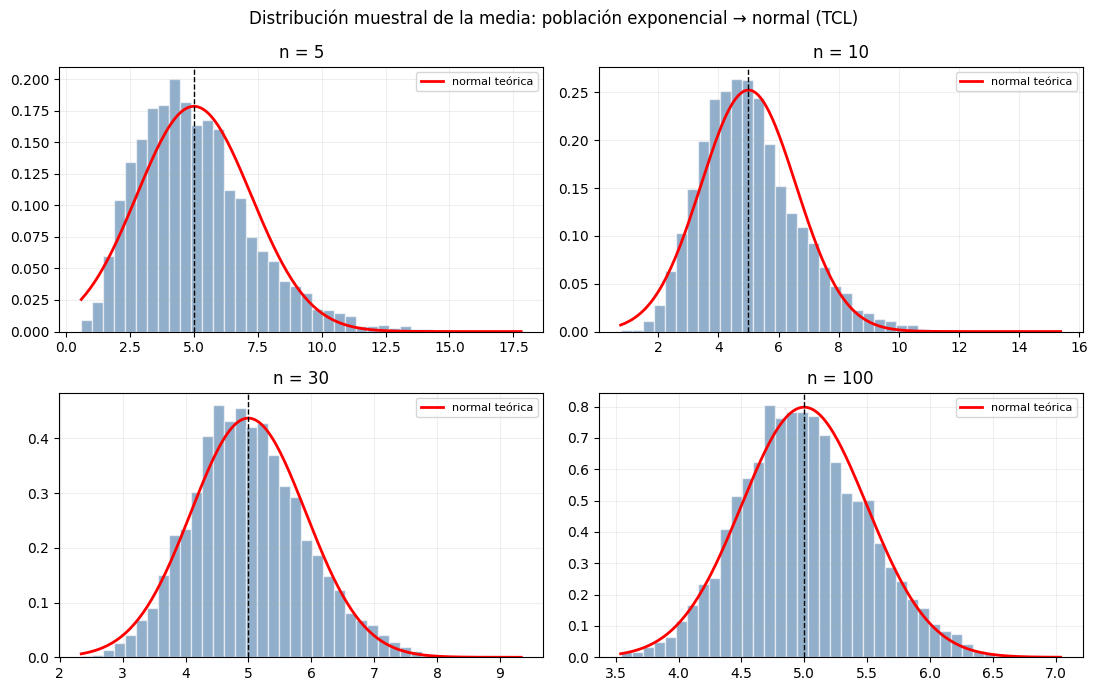

In [8]:
# --- Visualización del TCL (agregada al convertir: el examplebox se
#     titula "Visualización…" pero el listado solo imprime la tabla) ---
import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, n in zip(axes.ravel(), [5, 10, 30, 100]):
    medias = np.array([
        rng.choice(poblacion, size=n, replace=False).mean()
        for _ in range(5000)
    ])
    ax.hist(medias, bins=40, density=True, alpha=0.6,
            color="#4878a8", edgecolor="white")
    xs = np.linspace(medias.min(), medias.max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, mu_real, sigma_real / np.sqrt(n)),
            "r-", linewidth=2, label="normal teórica")
    ax.axvline(mu_real, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"n = {n}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
fig.suptitle("Distribución muestral de la media: población exponencial → normal (TCL)",
             fontsize=12)
plt.tight_layout()
plt.show()

## 6. Propiedades de Buenos Estimadores

No todos los estimadores son iguales. Queremos estimadores con las siguientes propiedades:

### 6.1 Insesgamiento (Unbiasedness)

> **📘 Definición — Estimador Insesgado**
>
> Un estimador $\hat{\theta}$ es **insesgado** para el parámetro $\theta$ si:
>
> $$E[\hat{\theta}] = \theta$$
>
> En promedio (sobre todas las muestras posibles), el estimador es igual al parámetro verdadero.
>
> **Sesgo:** Si el estimador no es insesgado, su sesgo es:
>
> $$\text{Sesgo}(\hat{\theta}) = E[\hat{\theta}] - \theta$$

**Ejemplos:**

- $\bar{X}$ es insesgado para $\mu$: $E[\bar{X}] = \mu$.
- $S^2 = \frac{1}{n-1}\sum(X_i - \bar{X})^2$ es insesgado para $\sigma^2$.
- $\frac{1}{n}\sum(X_i - \bar{X})^2$ es sesgado para $\sigma^2$ (por eso usamos $n-1$).

### 6.2 Consistencia

> **📘 Definición — Estimador Consistente**
>
> Un estimador $\hat{\theta}_n$ es **consistente** para $\theta$ si converge en probabilidad a $\theta$ cuando $n \to \infty$:
>
> $$\hat{\theta}_n \xrightarrow{P} \theta \quad \text{cuando } n \to \infty$$
>
> La LGN garantiza que $\bar{X}_n$ es consistente para $\mu$.

**Condición suficiente para consistencia:** Si un estimador es insesgado y su varianza tiende a cero cuando $n \to \infty$, entonces es consistente. Para $\bar{X}$: es insesgado ($E[\bar{X}] = \mu$) y $\text{Var}(\bar{X}) = \sigma^2/n \to 0$, por lo tanto es consistente.

### 6.3 Eficiencia

> **📘 Definición — Eficiencia**
>
> Entre dos estimadores insesgados, el más **eficiente** es el que tiene menor varianza.
>
> Si $\hat{\theta}_1$ y $\hat{\theta}_2$ son ambos insesgados para $\theta$, y $\text{Var}(\hat{\theta}_1) < \text{Var}(\hat{\theta}_2)$, entonces $\hat{\theta}_1$ es más eficiente.
>
> **Cota de Cramér-Rao:** Establece un límite inferior para la varianza de estimadores insesgados. Un estimador que alcanza esta cota es el más eficiente posible.

**Ejemplo:** Para estimar la media de una distribución normal, $\bar{X}$ es insesgado y eficiente, mientras que la mediana muestral también es insesgada pero menos eficiente (mayor varianza). Para distribuciones normales, $\bar{X}$ es el estimador óptimo.

> **🟢 Ejemplo — Comparación: Media vs. Mediana como Estimadores**

In [9]:
import numpy as np

rng = np.random.default_rng(42)
mu, sigma, n = 50, 10, 30
n_muestras = 10000

medias   = np.zeros(n_muestras)
medianas = np.zeros(n_muestras)

for i in range(n_muestras):
    muestra   = rng.normal(mu, sigma, size=n)
    medias[i]   = muestra.mean()
    medianas[i] = np.median(muestra)

print("Comparación de estimadores (n=30, distribución normal):")
print("-" * 60)
print(f"Media de las medias:    {medias.mean():.4f}")
print(f"Media de las medianas:  {medianas.mean():.4f}")
print(f"(Ambos cercanos a μ = {mu}, ambos insesgados)")
print()
print(f"Desv.Est de las medias:    {medias.std():.4f}")
print(f"Desv.Est de las medianas:  {medianas.std():.4f}")
print(f"(La media tiene menor varianza → más eficiente)")

Comparación de estimadores (n=30, distribución normal):
------------------------------------------------------------
Media de las medias:    50.0004
Media de las medianas:  49.9810
(Ambos cercanos a μ = 50, ambos insesgados)

Desv.Est de las medias:    1.8149
Desv.Est de las medianas:  2.2333
(La media tiene menor varianza → más eficiente)


## 7. Error Cuadrático Medio (MSE)

> **📘 Definición — Error Cuadrático Medio**
>
> El **MSE** combina sesgo y varianza en una sola medida:
>
> $$MSE(\hat{\theta}) = E\!\left[(\hat{\theta} - \theta)^2\right] = \text{Sesgo}^2(\hat{\theta}) + \text{Var}(\hat{\theta})$$
>
> **Descomposición:**
> - Si $\hat{\theta}$ es insesgado: $MSE = \text{Var}(\hat{\theta})$.
> - Si $\hat{\theta}$ es sesgado: hay un trade-off entre sesgo y varianza.

**Trade-off Sesgo-Varianza:** A veces un estimador ligeramente sesgado con menor varianza puede tener menor MSE que un estimador insesgado con alta varianza. Este es un concepto fundamental en machine learning.

## 8. Aplicaciones Prácticas

### 8.1 Determinar Tamaño de Muestra

**Pregunta práctica:** ¿Cuántos datos necesito para estimar $\mu$ con precisión $\pm\epsilon$ y confianza del 95%?

Usando el Teorema Central del Límite y propiedades de la distribución normal:

$$n \geq \left(\frac{1.96 \cdot \sigma}{\epsilon}\right)^2$$

donde 1.96 es el valor crítico para 95% de confianza.

In [10]:
import numpy as np
from scipy import stats

def calcular_tamaño_muestra(sigma, epsilon, confianza=0.95):
    """
    Calcular tamaño de muestra necesario.

    Parameters
    ----------
    sigma     : Desviación estándar poblacional (estimada)
    epsilon   : Error máximo deseado (margen de error)
    confianza : Nivel de confianza (default 0.95)

    Returns
    -------
    n : int  — tamaño de muestra necesario
    """
    alpha = 1 - confianza
    z = stats.norm.ppf(1 - alpha / 2)
    return int(np.ceil((z * sigma / epsilon) ** 2))

sigma_est = 15  # Desviación estimada (estudio piloto)

print("Tamaño de muestra necesario para diferentes precisiones:")
print("-" * 60)
for epsilon in [5, 3, 2, 1, 0.5]:
    n = calcular_tamaño_muestra(sigma_est, epsilon)
    print(f"Error ±{epsilon:>4}: n = {n:>6} muestras")

print("\nObservación: para reducir el error a la mitad,")
print("se necesitan aproximadamente 4 veces más muestras.")

Tamaño de muestra necesario para diferentes precisiones:
------------------------------------------------------------
Error ±   5: n =     35 muestras
Error ±   3: n =     97 muestras
Error ±   2: n =    217 muestras
Error ±   1: n =    865 muestras
Error ± 0.5: n =   3458 muestras

Observación: para reducir el error a la mitad,
se necesitan aproximadamente 4 veces más muestras.


### 8.2 Intervalos de Confianza

Un intervalo de confianza del 95% para $\mu$ es:

$$\bar{x} \pm 1.96 \cdot \frac{s}{\sqrt{n}}$$

donde $s$ es la desviación estándar muestral.

In [11]:
import numpy as np
from scipy import stats

def intervalo_confianza(datos, confianza=0.95):
    """Calcular intervalo de confianza para la media."""
    n     = len(datos)
    media = datos.mean()
    se    = datos.std(ddof=1) / np.sqrt(n)

    alpha  = 1 - confianza
    t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
    margen = t_crit * se

    return media, (media - margen, media + margen)

rng  = np.random.default_rng(42)
datos = rng.normal(loc=100, scale=15, size=50)

media, (lower, upper) = intervalo_confianza(datos)

print(f"Datos: n = {len(datos)}")
print(f"Media muestral: {media:.2f}")
print(f"IC 95%: [{lower:.2f}, {upper:.2f}]")
print(f"\nInterpretación: Con 95% de confianza, "
      f"μ está entre {lower:.2f} y {upper:.2f}.")

Datos: n = 50
Media muestral: 101.37
IC 95%: [98.09, 104.64]

Interpretación: Con 95% de confianza, μ está entre 98.09 y 104.64.


## 9. Resumen y Puntos Clave

1. **Parámetros** son características fijas (pero desconocidas) de la población. **Estimadores** son funciones de los datos muestrales que varían entre muestras.
2. La **Ley de los Grandes Números** garantiza que el promedio muestral converge al promedio poblacional cuando $n \to \infty$.
3. Existen dos versiones: débil (convergencia en probabilidad) y fuerte (convergencia casi segura). Ambas justifican la inferencia estadística.
4. Los estimadores tienen **variabilidad** inherente. El error estándar $SE = \sigma/\sqrt{n}$ cuantifica esa variabilidad.
5. El error estándar disminuye con $1/\sqrt{n}$: para reducirlo a la mitad se necesitan 4 veces más datos.
6. Un buen estimador es: **insesgado** (correcto en promedio), **consistente** (converge al parámetro) y **eficiente** (mínima varianza).
7. El **MSE** combina sesgo y varianza. A veces existe un trade-off entre ambos.
8. El **Teorema Central del Límite** complementa la LGN: describe la *forma* de la distribución muestral (aproximadamente normal para $n$ grande).
9. Estas teorías fundamentan prácticamente todas las técnicas de inferencia estadística: intervalos de confianza, pruebas de hipótesis, y más.

### Cierre

> 💡 La Ley de los Grandes Números es el puente entre la teoría probabilística y la práctica estadística. Justifica matemáticamente por qué podemos aprender sobre poblaciones completas observando solo muestras. Al mismo tiempo, nos recuerda que siempre existe incertidumbre: los estimadores varían y debemos cuantificar esa variabilidad. La estadística moderna proporciona herramientas rigurosas para hacer inferencias válidas reconociendo esta incertidumbre inherente, convirtiendo la imprecisión en conocimiento accionable.